# DigitVision – Handwritten Digit Recognition using CNN

# Introduction

Handwritten digit recognition is an important application in the field of computer vision and deep learning. This project aims to build a model that can recognize handwritten digits from images using a Convolutional Neural Network (CNN). The model is trained using the MNIST Dataset, which contains thousands of labeled images of handwritten digits from 0 to 9. Using TensorFlow and Keras, the system learns patterns such as edges, shapes, and curves present in digit images. After training, the model can accurately classify new handwritten digit images.

### Import Libraries 

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D,MaxPooling2D
from tensorflow.keras.datasets import mnist

### Load the Dataset

In [19]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


### Display an Image

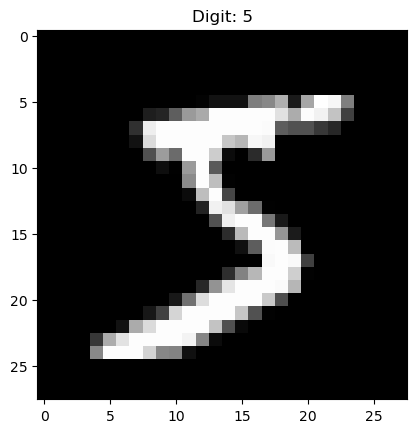

In [20]:
plt.imshow(x_train[0], cmap='gray')
plt.title("Digit: " + str(y_train[0]))
plt.show()

### Data Preprocessing

In [21]:
#normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

In [22]:
#Reshape for CNN
x_train = x_train.reshape((60000,28,28,1))
x_test = x_test.reshape((10000,28,28,1))

### Build the CNN Model

In [23]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(layers.Flatten())

model.add(layers.Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(layers.Dense(10,activation='softmax'))

### View Model Architecture

In [24]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 13, 13, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 5, 5, 64)          0         
                                                                 
 flatten_3 (Flatten)         (None, 1600)             

### Compile the Model

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train the Model

In [26]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

Epoch 1/5


1875/1875 [==============================] - 52s 25ms/step - loss: 0.3088 - accuracy: 0.9040 - val_loss: 0.0538 - val_accuracy: 0.9822
Epoch 2/5
1875/1875 [==============================] - 45s 24ms/step - loss: 0.1336 - accuracy: 0.9604 - val_loss: 0.0422 - val_accuracy: 0.9852
Epoch 3/5
1875/1875 [==============================] - 47s 25ms/step - loss: 0.1038 - accuracy: 0.9692 - val_loss: 0.0357 - val_accuracy: 0.9871
Epoch 4/5
1875/1875 [==============================] - 45s 24ms/step - loss: 0.0871 - accuracy: 0.9734 - val_loss: 0.0308 - val_accuracy: 0.9899
Epoch 5/5
1875/1875 [==============================] - 45s 24ms/step - loss: 0.0774 - accuracy: 0.9765 - val_loss: 0.0307 - val_accuracy: 0.9900


### Make Predictions

In [31]:
predictions = model.predict(x_test)

print("Actual Digit:", y_test[index])
print("Predicted Digit:", np.argmax(predictions[0]))

313/313 [==============================] - 3s 10ms/step
Actual Digit: 7
Predicted Digit: 7


### Show Prediction Image

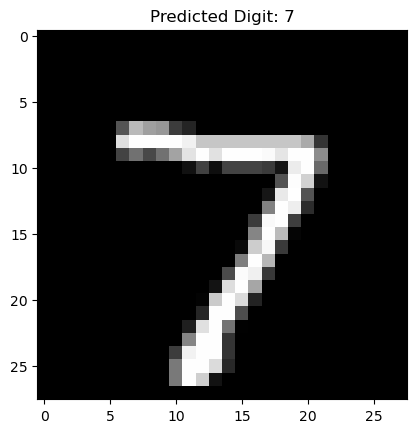

In [28]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted Digit: " + str(np.argmax(predictions[0])))
plt.show()

# Conclusion

In this project, a handwritten digit recognition system was developed using a CNN model. The model was trained and evaluated using the MNIST dataset to classify digits from 0 to 9. The results show that deep learning models can effectively learn patterns from image data and provide accurate predictions. This project helped in understanding the fundamentals of image classification, CNN architecture, and model training using TensorFlow and Keras.